# 05 — Deep Neural Network for Customer Churn Prediction

This notebook implements the DNN stage of the Telco Customer Churn project.

**Methodology**
- Reproduce the preprocessing used by the existing baseline notebook.
- Hold out the test set before validation/tuning.
- Fit preprocessing only on the training fold.
- Compare several DNN architectures/hyperparameters using validation metrics.
- Select the best DNN using validation F1-score (with ROC-AUC/recall/accuracy as supporting metrics).
- Evaluate the selected DNN once on the untouched test set.
- Compare the final DNN against Logistic Regression, Decision Tree and Random Forest.
- Save the final DNN, fitted preprocessor, experiment results and metadata.

**Important:** The test set is not used during DNN experiment selection.

## 1. Imports and reproducibility

In [1]:
import os
import random
import time
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import tensorflow as tf

from tensorflow.keras import layers, models, callbacks, regularizers

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve,
    classification_report
)

SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("Random seed:", SEED)

TensorFlow version: 2.21.0
Random seed: 42


## 2. Load the IBM Telco Customer Churn dataset

In [2]:
data_path = os.path.join("..", "data", "WA_Fn-UseC_-Telco-Customer-Churn.csv")

if not os.path.exists(data_path):
    raise FileNotFoundError(
        f"Dataset not found at {data_path}. "
        "Run this notebook from the project's notebooks/ directory."
    )

df = pd.read_csv(data_path)

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 3. Reproduce the existing preprocessing definition

In [3]:
# Remove customer identifier.
df = df.drop("customerID", axis=1)

# Convert TotalCharges to numeric; blank strings become NaN.
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Separate predictors and target.
X = df.drop("Churn", axis=1)
y = df["Churn"].map({"No": 0, "Yes": 1})

if y.isna().any():
    raise ValueError("Unexpected target values found in Churn.")

print("Predictor shape:", X.shape)
print("Target distribution:")
print(y.value_counts(normalize=True).rename("proportion"))
print("\nMissing values:")
print(X.isna().sum().sort_values(ascending=False).head())

Predictor shape: (7043, 19)
Target distribution:
Churn
0    0.73463
1    0.26537
Name: proportion, dtype: float64

Missing values:
TotalCharges        11
DeviceProtection     0
MonthlyCharges       0
PaymentMethod        0
PaperlessBilling     0
dtype: int64


## 4. Train/test split — keep the test set untouched

In [4]:
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=SEED,
    stratify=y
)

print("Training pool:", X_train_full.shape)
print("Test set:", X_test.shape)

Training pool: (5634, 19)
Test set: (1409, 19)


## 5. Train/validation split for DNN tuning

In [5]:
X_train_tr, X_val, y_train_tr, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.20,
    random_state=SEED,
    stratify=y_train_full
)

print("Training fold:", X_train_tr.shape)
print("Validation fold:", X_val.shape)
print("Test fold:", X_test.shape)

Training fold: (4507, 19)
Validation fold: (1127, 19)
Test fold: (1409, 19)


## 6. Fit preprocessing ONLY on the training fold

In [6]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(
        handle_unknown="ignore",
        drop="first"
    ))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

# CRITICAL: fit only on X_train_tr.
X_train_processed = preprocessor.fit_transform(X_train_tr)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

# Keras expects dense arrays.
if hasattr(X_train_processed, "toarray"):
    X_train_processed = X_train_processed.toarray()
    X_val_processed = X_val_processed.toarray()
    X_test_processed = X_test_processed.toarray()

ohe = preprocessor.named_transformers_["cat"]["onehot"]
ohe_columns = ohe.get_feature_names_out(categorical_features)
feature_names = numeric_features + ohe_columns.tolist()

print("Number of transformed features:", len(feature_names))
print("Train:", X_train_processed.shape)
print("Validation:", X_val_processed.shape)
print("Test:", X_test_processed.shape)

Number of transformed features: 30
Train: (4507, 30)
Validation: (1127, 30)
Test: (1409, 30)


## 7. Prepare NumPy inputs and verify data

In [7]:
X_train_np = np.asarray(X_train_processed, dtype=np.float32)
X_val_np = np.asarray(X_val_processed, dtype=np.float32)
X_test_np = np.asarray(X_test_processed, dtype=np.float32)

y_train_np = y_train_tr.to_numpy(dtype=np.float32)
y_val_np = y_val.to_numpy(dtype=np.float32)
y_test_np = y_test.to_numpy(dtype=np.float32)

print("X_train_np:", X_train_np.shape)
print("X_val_np:  ", X_val_np.shape)
print("X_test_np: ", X_test_np.shape)

print("\nNaN counts:")
print("Train:", np.isnan(X_train_np).sum())
print("Val:  ", np.isnan(X_val_np).sum())
print("Test: ", np.isnan(X_test_np).sum())

if not np.isfinite(X_train_np).all():
    raise ValueError("Non-finite values found in X_train_np.")
if not np.isfinite(X_val_np).all():
    raise ValueError("Non-finite values found in X_val_np.")
if not np.isfinite(X_test_np).all():
    raise ValueError("Non-finite values found in X_test_np.")

X_train_np: (4507, 30)
X_val_np:   (1127, 30)
X_test_np:  (1409, 30)

NaN counts:
Train: 0
Val:   0
Test:  0


## 8. DNN model, training and evaluation helpers

In [8]:
def build_dnn_model(
    input_shape,
    hidden_units=(64, 32, 16),
    dropout_rate=0.5,
    learning_rate=1e-3,
    l2_rate=0.0
):
    model = models.Sequential()
    model.add(layers.Input(shape=(input_shape,)))

    for units in hidden_units:
        model.add(
            layers.Dense(
                units,
                activation="relu",
                kernel_regularizer=(
                    regularizers.l2(l2_rate)
                    if l2_rate > 0 else None
                )
            )
        )
        model.add(layers.Dropout(dropout_rate))

    model.add(layers.Dense(1, activation="sigmoid"))

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=learning_rate
        ),
        loss="binary_crossentropy",
        metrics=[
            tf.keras.metrics.BinaryAccuracy(name="accuracy"),
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall"),
            tf.keras.metrics.AUC(name="roc_auc")
        ]
    )

    return model


def train_dnn_model(
    model,
    X_train,
    y_train,
    X_val,
    y_val,
    batch_size=32,
    max_epochs=100,
    patience=8
):
    early_stop = callbacks.EarlyStopping(
        monitor="val_loss",
        patience=patience,
        restore_best_weights=True,
        verbose=1
    )

    start_time = time.time()

    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=max_epochs,
        batch_size=batch_size,
        callbacks=[early_stop],
        verbose=1
    )

    train_time_s = time.time() - start_time

    return model, history, train_time_s


def evaluate_binary_model(model, X_data, y_data, threshold=0.5):
    y_prob = model.predict(X_data, verbose=0).ravel()
    y_pred = (y_prob >= threshold).astype(int)

    return {
        "accuracy": accuracy_score(y_data, y_pred),
        "precision": precision_score(y_data, y_pred, zero_division=0),
        "recall": recall_score(y_data, y_pred, zero_division=0),
        "f1": f1_score(y_data, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_data, y_prob),
        "y_pred": y_pred,
        "y_prob": y_prob
    }

## 9. Project baseline DNN

In [9]:
baseline_config = {
    "name": "B-Baseline-DNN",
    "hidden_units": (64, 32, 16),
    "dropout": 0.5,
    "learning_rate": 1e-3,
    "batch_size": 32,
    "max_epochs": 100,
    "l2_rate": 0.0
}

tf.keras.backend.clear_session()
tf.random.set_seed(SEED)
np.random.seed(SEED)

baseline_model = build_dnn_model(
    input_shape=X_train_np.shape[1],
    hidden_units=baseline_config["hidden_units"],
    dropout_rate=baseline_config["dropout"],
    learning_rate=baseline_config["learning_rate"],
    l2_rate=baseline_config["l2_rate"]
)

baseline_model.summary()

baseline_model, baseline_history, baseline_train_time = train_dnn_model(
    baseline_model,
    X_train_np,
    y_train_np,
    X_val_np,
    y_val_np,
    batch_size=baseline_config["batch_size"],
    max_epochs=baseline_config["max_epochs"]
)

baseline_val_metrics = evaluate_binary_model(
    baseline_model,
    X_val_np,
    y_val_np
)

print("\nBaseline DNN validation metrics")
for key in ["accuracy", "precision", "recall", "f1", "roc_auc"]:
    print(f"{key:10s}: {baseline_val_metrics[key]:.4f}")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,609 (18.00 KB)

 Trainable params: 4,609 (18.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6414 - loss: 0.6336 - precision: 0.2682 - recall: 0.2032 - roc_auc: 0.5584 - val_accuracy: 0.7356 - val_loss: 0.4933 - val_precision: 1.0000 - val_recall: 0.0033 - val_roc_auc: 0.8248
Epoch 2/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7417 - loss: 0.5128 - precision: 0.5606 - recall: 0.1237 - roc_auc: 0.7341 - val_accuracy: 0.7684 - val_loss: 0.4448 - val_precision: 0.7639 - val_recall: 0.1839 - val_roc_auc: 0.8372
Epoch 3/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7519 - loss: 0.5026 - precision: 0.5855 - recall: 0.2232 - roc_auc: 0.7640 - val_accuracy: 0.7844 - val_loss: 0.4421 - val_precision: 0.7373 - val_recall: 0.2910 - val_roc_auc: 0.8401
Epoch 4/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7562 - loss: 0.4882 - precision: 0.5942 - recall: 0.2559 - roc_auc: 0.7751 - val_accuracy: 0.8057 - val_loss: 0.4365 - val_precision: 0.7247 - val_recall: 0.4314 - val_roc_auc: 0.8

## 10. Baseline DNN training curves

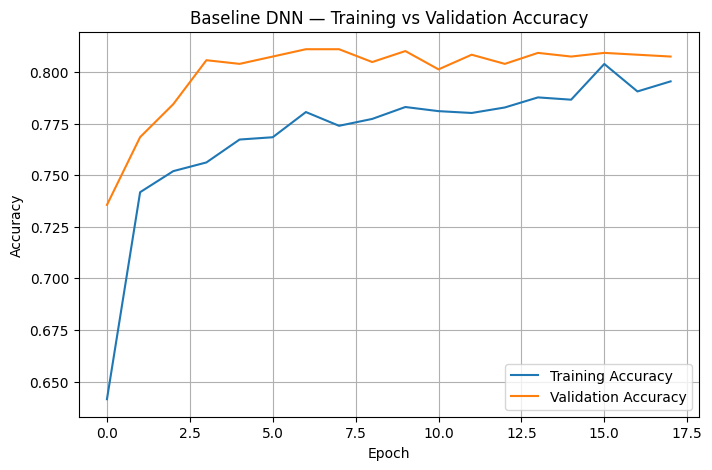

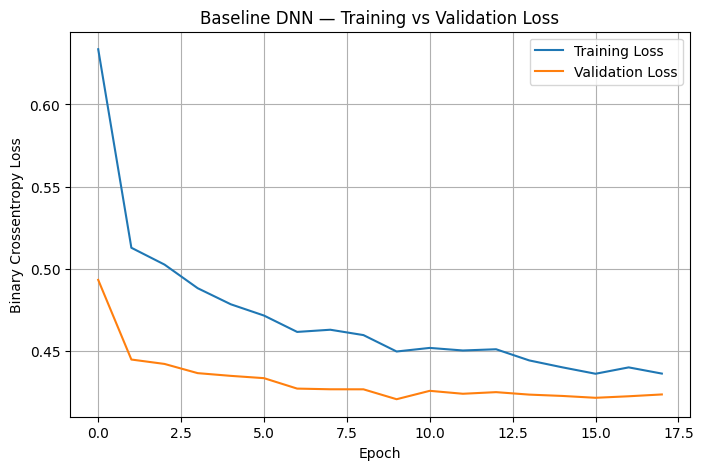

In [10]:
plt.figure(figsize=(8, 5))
plt.plot(baseline_history.history["accuracy"], label="Training Accuracy")
plt.plot(baseline_history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Baseline DNN — Training vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(baseline_history.history["loss"], label="Training Loss")
plt.plot(baseline_history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Binary Crossentropy Loss")
plt.title("Baseline DNN — Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

## 11. Controlled DNN experiments

In [11]:
# Each configuration changes one meaningful factor relative to the project baseline.
# The duplicate F-LR-1e-3 configuration is intentionally removed because it is
# identical to B-Baseline-DNN.

experiment_configs = [
    {
        "name": "A-Small-DNN",
        "hidden_units": (32, 16, 8),
        "dropout": 0.5,
        "learning_rate": 1e-3,
        "batch_size": 32,
        "max_epochs": 100,
        "l2_rate": 0.0
    },
    {
        "name": "B-Baseline-DNN",
        "hidden_units": (64, 32, 16),
        "dropout": 0.5,
        "learning_rate": 1e-3,
        "batch_size": 32,
        "max_epochs": 100,
        "l2_rate": 0.0
    },
    {
        "name": "C-Wider-DNN",
        "hidden_units": (128, 64, 32),
        "dropout": 0.5,
        "learning_rate": 1e-3,
        "batch_size": 32,
        "max_epochs": 100,
        "l2_rate": 0.0
    },
    {
        "name": "D-Deeper-DNN",
        "hidden_units": (128, 64, 32, 16),
        "dropout": 0.5,
        "learning_rate": 1e-3,
        "batch_size": 32,
        "max_epochs": 100,
        "l2_rate": 0.0
    },
    {
        "name": "E-Lower-Dropout",
        "hidden_units": (64, 32, 16),
        "dropout": 0.2,
        "learning_rate": 1e-3,
        "batch_size": 32,
        "max_epochs": 100,
        "l2_rate": 0.0
    },
    {
        "name": "F-LR-3e-4",
        "hidden_units": (64, 32, 16),
        "dropout": 0.5,
        "learning_rate": 3e-4,
        "batch_size": 32,
        "max_epochs": 100,
        "l2_rate": 0.0
    },
    {
        "name": "F-LR-1e-4",
        "hidden_units": (64, 32, 16),
        "dropout": 0.5,
        "learning_rate": 1e-4,
        "batch_size": 32,
        "max_epochs": 100,
        "l2_rate": 0.0
    },
    {
        "name": "G-Batch-64",
        "hidden_units": (64, 32, 16),
        "dropout": 0.5,
        "learning_rate": 1e-3,
        "batch_size": 64,
        "max_epochs": 100,
        "l2_rate": 0.0
    },
    {
        "name": "H-L2-Regularized",
        "hidden_units": (64, 32, 16),
        "dropout": 0.5,
        "learning_rate": 1e-3,
        "batch_size": 32,
        "max_epochs": 100,
        "l2_rate": 1e-4
    }
]

print("Number of DNN configurations:", len(experiment_configs))

Number of DNN configurations: 9


## 12. Run experiments — validation metrics only

In [12]:
experiment_results = []

for cfg in experiment_configs:
    print("\n" + "=" * 70)
    print("Running:", cfg["name"])
    print("=" * 70)

    tf.keras.backend.clear_session()
    tf.random.set_seed(SEED)
    np.random.seed(SEED)

    model = build_dnn_model(
        input_shape=X_train_np.shape[1],
        hidden_units=cfg["hidden_units"],
        dropout_rate=cfg["dropout"],
        learning_rate=cfg["learning_rate"],
        l2_rate=cfg["l2_rate"]
    )

    model, history, train_time_s = train_dnn_model(
        model,
        X_train_np,
        y_train_np,
        X_val_np,
        y_val_np,
        batch_size=cfg["batch_size"],
        max_epochs=cfg["max_epochs"]
    )

    val_metrics = evaluate_binary_model(
        model,
        X_val_np,
        y_val_np
    )

    experiment_results.append({
        "experiment_name": cfg["name"],
        "architecture": "-".join(str(x) for x in cfg["hidden_units"]),
        "n_parameters": model.count_params(),
        "dropout": cfg["dropout"],
        "learning_rate": cfg["learning_rate"],
        "batch_size": cfg["batch_size"],
        "epochs_trained": len(history.history["loss"]),
        "train_time_s": round(train_time_s, 2),
        "val_accuracy": val_metrics["accuracy"],
        "val_precision": val_metrics["precision"],
        "val_recall": val_metrics["recall"],
        "val_f1": val_metrics["f1"],
        "val_roc_auc": val_metrics["roc_auc"]
    })

experiment_df = pd.DataFrame(experiment_results)

display(
    experiment_df.sort_values(
        by=["val_f1", "val_roc_auc"],
        ascending=False
    )
)


Running: A-Small-DNN
Epoch 1/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6270 - loss: 0.6652 - precision: 0.2889 - recall: 0.2776 - roc_auc: 0.5497 - val_accuracy: 0.7347 - val_loss: 0.5385 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - val_roc_auc: 0.8120
Epoch 2/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7202 - loss: 0.5729 - precision: 0.3488 - recall: 0.0627 - roc_auc: 0.6272 - val_accuracy: 0.7347 - val_loss: 0.4824 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - val_roc_auc: 0.8287
Epoch 3/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7280 - loss: 0.5444 - precision: 0.3333 - recall: 0.0251 - roc_auc: 0.6762 - val_accuracy: 0.7347 - val_loss: 0.4675 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - val_roc_auc: 0.8309
Epoch 4/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7371 - loss: 0.5264 - precision: 0.5556 - recall: 0.0460 - roc_auc: 0.7178 - val_accuracy: 0.7347 - val_loss: 0.4556 - val_precision: 

,experiment_name,architecture,n_parameters,dropout,learning_rate,batch_size,epochs_trained,train_time_s,val_accuracy,val_precision,val_recall,val_f1,val_roc_auc
5,F-LR-3e-4,64-32-16,4609,0.5,0.0003,32,56,19.24,0.815439,0.685714,0.561873,0.617647,0.848222
2,C-Wider-DNN,128-64-32,14337,0.5,0.0010,32,36,14.30,0.816327,0.691667,0.555184,0.615955,0.844138
3,D-Deeper-DNN,128-64-32-16,14849,0.5,0.0010,32,33,12.54,0.808341,0.664032,0.561873,0.608696,0.843973
4,E-Lower-Dropout,64-32-16,4609,0.2,0.0010,32,14,5.80,0.808341,0.665339,0.558528,0.607273,0.847006
1,B-Baseline-DNN,64-32-16,4609,0.5,0.0010,32,38,12.81,0.812777,0.686441,0.541806,0.605607,0.844684
6,F-LR-1e-4,64-32-16,4609,0.5,0.0001,32,100,32.57,0.812777,0.686441,0.541806,0.605607,0.843042
8,H-L2-Regularized,64-32-16,4609,0.5,0.0010,32,37,12.92,0.814552,0.695652,0.535117,0.604915,0.847531
7,G-Batch-64,64-32-16,4609,0.5,0.0010,64,33,10.78,0.810115,0.690583,0.515050,0.590038,0.843161
0,A-Small-DNN,32-16-8,1665,0.5,0.0010,32,25,8.67,0.798580,0.702247,0.418060,0.524109,0.843173


## 13. Select the best DNN using validation results

In [13]:
# Primary selection metric: validation F1.
# ROC-AUC, recall and accuracy are used as supporting evidence.

ranking_df = experiment_df.sort_values(
    by=["val_f1", "val_roc_auc", "val_recall"],
    ascending=False
).reset_index(drop=True)

selected_experiment_name = ranking_df.loc[0, "experiment_name"]

selected_config = next(
    cfg for cfg in experiment_configs
    if cfg["name"] == selected_experiment_name
)

print("Selected DNN:", selected_experiment_name)
print("\nValidation ranking:")
display(ranking_df)

print("\nSelected configuration:")
print(selected_config)

Selected DNN: F-LR-3e-4

Validation ranking:


,experiment_name,architecture,n_parameters,dropout,learning_rate,batch_size,epochs_trained,train_time_s,val_accuracy,val_precision,val_recall,val_f1,val_roc_auc
0,F-LR-3e-4,64-32-16,4609,0.5,0.0003,32,56,19.24,0.815439,0.685714,0.561873,0.617647,0.848222
1,C-Wider-DNN,128-64-32,14337,0.5,0.0010,32,36,14.30,0.816327,0.691667,0.555184,0.615955,0.844138
2,D-Deeper-DNN,128-64-32-16,14849,0.5,0.0010,32,33,12.54,0.808341,0.664032,0.561873,0.608696,0.843973
3,E-Lower-Dropout,64-32-16,4609,0.2,0.0010,32,14,5.80,0.808341,0.665339,0.558528,0.607273,0.847006
4,B-Baseline-DNN,64-32-16,4609,0.5,0.0010,32,38,12.81,0.812777,0.686441,0.541806,0.605607,0.844684
5,F-LR-1e-4,64-32-16,4609,0.5,0.0001,32,100,32.57,0.812777,0.686441,0.541806,0.605607,0.843042
6,H-L2-Regularized,64-32-16,4609,0.5,0.0010,32,37,12.92,0.814552,0.695652,0.535117,0.604915,0.847531
7,G-Batch-64,64-32-16,4609,0.5,0.0010,64,33,10.78,0.810115,0.690583,0.515050,0.590038,0.843161
8,A-Small-DNN,32-16-8,1665,0.5,0.0010,32,25,8.67,0.798580,0.702247,0.418060,0.524109,0.843173



Selected configuration:
{'name': 'F-LR-3e-4', 'hidden_units': (64, 32, 16), 'dropout': 0.5, 'learning_rate': 0.0003, 'batch_size': 32, 'max_epochs': 100, 'l2_rate': 0.0}


## 14. Final selected DNN — test evaluation

In [14]:
# Rebuild the selected architecture with the same train/validation methodology.
# The test set is used ONLY here for final evaluation.

tf.keras.backend.clear_session()
tf.random.set_seed(SEED)
np.random.seed(SEED)

selected_model = build_dnn_model(
    input_shape=X_train_np.shape[1],
    hidden_units=selected_config["hidden_units"],
    dropout_rate=selected_config["dropout"],
    learning_rate=selected_config["learning_rate"],
    l2_rate=selected_config["l2_rate"]
)

selected_model, selected_history, selected_train_time_s = train_dnn_model(
    selected_model,
    X_train_np,
    y_train_np,
    X_val_np,
    y_val_np,
    batch_size=selected_config["batch_size"],
    max_epochs=selected_config["max_epochs"]
)

test_metrics = evaluate_binary_model(
    selected_model,
    X_test_np,
    y_test_np,
    threshold=0.5
)

print("FINAL SELECTED DNN — TEST RESULTS")
print("-" * 45)
for metric in ["accuracy", "precision", "recall", "f1", "roc_auc"]:
    print(f"{metric:10s}: {test_metrics[metric]:.4f}")

Epoch 1/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5447 - loss: 0.6896 - precision: 0.2769 - recall: 0.4440 - roc_auc: 0.5263 - val_accuracy: 0.7347 - val_loss: 0.6139 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - val_roc_auc: 0.7761
Epoch 2/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6927 - loss: 0.6082 - precision: 0.3266 - recall: 0.1488 - roc_auc: 0.5768 - val_accuracy: 0.7347 - val_loss: 0.5396 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - val_roc_auc: 0.8132
Epoch 3/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7240 - loss: 0.5565 - precision: 0.4118 - recall: 0.0936 - roc_auc: 0.6564 - val_accuracy: 0.7347 - val_loss: 0.4963 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - val_roc_auc: 0.8234
Epoch 4/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7318 - loss: 0.5486 - precision: 0.4728 - recall: 0.0945 - roc_auc: 0.6769 - val_accuracy: 0.7347 - val_loss: 0.4820 - val_precision: 0.0000e+00 - val_recal

## 15. Final DNN confusion matrix and ROC curve

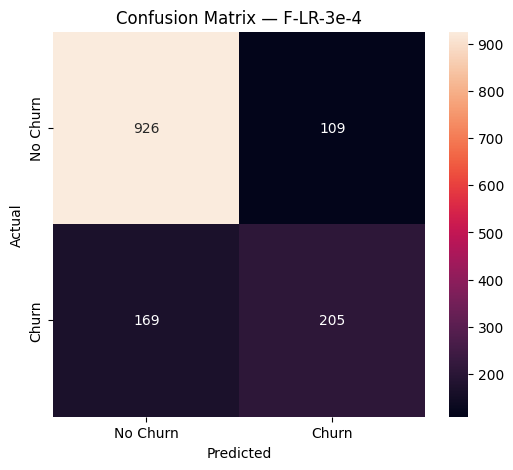

Classification report:
              precision    recall  f1-score   support

    No Churn       0.85      0.89      0.87      1035
       Churn       0.65      0.55      0.60       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.79      0.80      0.80      1409



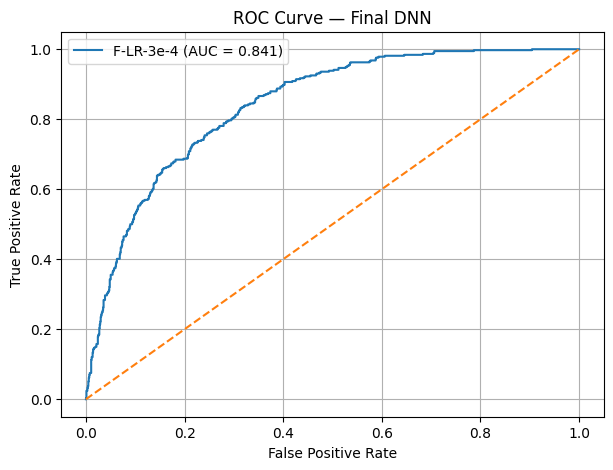

In [15]:
cm = confusion_matrix(
    y_test_np,
    test_metrics["y_pred"]
)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix — {selected_experiment_name}")
plt.show()

print("Classification report:")
print(
    classification_report(
        y_test_np,
        test_metrics["y_pred"],
        target_names=["No Churn", "Churn"],
        zero_division=0
    )
)

fpr, tpr, _ = roc_curve(
    y_test_np,
    test_metrics["y_prob"]
)

plt.figure(figsize=(7, 5))
plt.plot(
    fpr,
    tpr,
    label=f"{selected_experiment_name} (AUC = {test_metrics['roc_auc']:.3f})"
)
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Final DNN")
plt.legend()
plt.grid(True)
plt.show()

## 16. Compare final DNN with existing ML baselines

In [16]:
# These are the final test metrics reported by 04_Baseline_Models.ipynb.
# They are not used for DNN tuning.

baseline_results = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "Accuracy": 0.8055358410220014,
        "Precision": 0.6572327044025157,
        "Recall": 0.5588235294117647,
        "F1-score": 0.6040462427745664,
        "ROC-AUC": 0.8420083184789068
    },
    {
        "Model": "Decision Tree",
        "Accuracy": 0.794180269694819,
        "Precision": 0.6296296296296297,
        "Recall": 0.5454545454545454,
        "F1-score": 0.5845272206303725,
        "ROC-AUC": 0.8283577462605594
    },
    {
        "Model": "Random Forest",
        "Accuracy": 0.7892122072391767,
        "Precision": 0.6305084745762712,
        "Recall": 0.49732620320855614,
        "F1-score": 0.5560538116591929,
        "ROC-AUC": 0.8225800201503525
    }
])

dnn_result = pd.DataFrame([{
    "Model": selected_experiment_name,
    "Accuracy": test_metrics["accuracy"],
    "Precision": test_metrics["precision"],
    "Recall": test_metrics["recall"],
    "F1-score": test_metrics["f1"],
    "ROC-AUC": test_metrics["roc_auc"]
}])

final_comparison = pd.concat(
    [baseline_results, dnn_result],
    ignore_index=True
)

display(final_comparison)

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.805536,0.657233,0.558824,0.604046,0.842008
1,Decision Tree,0.794180,0.629630,0.545455,0.584527,0.828358
2,Random Forest,0.789212,0.630508,0.497326,0.556054,0.822580
3,F-LR-3e-4,0.802697,0.652866,0.548128,0.595930,0.840939


## 17. Identify the overall best model

In [17]:
metric_winners = {
    "Accuracy": final_comparison.loc[
        final_comparison["Accuracy"].idxmax(), "Model"
    ],
    "Precision": final_comparison.loc[
        final_comparison["Precision"].idxmax(), "Model"
    ],
    "Recall": final_comparison.loc[
        final_comparison["Recall"].idxmax(), "Model"
    ],
    "F1-score": final_comparison.loc[
        final_comparison["F1-score"].idxmax(), "Model"
    ],
    "ROC-AUC": final_comparison.loc[
        final_comparison["ROC-AUC"].idxmax(), "Model"
    ]
}

print("Best model by metric:")
for metric, model_name in metric_winners.items():
    print(f"{metric:10s}: {model_name}")

print("\nNote:")
print(
    "For churn prediction, F1-score and recall should be considered "
    "alongside accuracy and ROC-AUC rather than choosing a model from "
    "accuracy alone."
)

Best model by metric:
Accuracy  : Logistic Regression
Precision : Logistic Regression
Recall    : Logistic Regression
F1-score  : Logistic Regression
ROC-AUC   : Logistic Regression

Note:
For churn prediction, F1-score and recall should be considered alongside accuracy and ROC-AUC rather than choosing a model from accuracy alone.


## 18. Save final DNN artifacts

In [18]:
models_dir = os.path.join("..", "models")
reports_dir = os.path.join("..", "reports")

os.makedirs(models_dir, exist_ok=True)
os.makedirs(reports_dir, exist_ok=True)

# Save selected DNN and fitted preprocessing pipeline.
model_path = os.path.join(models_dir, "churn_dnn_best.keras")
preprocessor_path = os.path.join(models_dir, "preprocessor.joblib")

selected_model.save(model_path)
joblib.dump(preprocessor, preprocessor_path)

# Save experiment and final comparison reports.
experiment_csv = os.path.join(reports_dir, "dnn_experiments.csv")
comparison_csv = os.path.join(reports_dir, "dnn_final_comparison.csv")

experiment_df.to_csv(experiment_csv, index=False)
final_comparison.to_csv(comparison_csv, index=False)

# Save test metrics separately.
final_metrics = {
    "model": selected_experiment_name,
    "accuracy": float(test_metrics["accuracy"]),
    "precision": float(test_metrics["precision"]),
    "recall": float(test_metrics["recall"]),
    "f1": float(test_metrics["f1"]),
    "roc_auc": float(test_metrics["roc_auc"]),
    "threshold": 0.5
}

metrics_path = os.path.join(reports_dir, "dnn_final_metrics.json")

with open(metrics_path, "w") as f:
    json.dump(final_metrics, f, indent=2)

print("Saved:")
print(model_path)
print(preprocessor_path)
print(experiment_csv)
print(comparison_csv)
print(metrics_path)

Saved:
..\models\churn_dnn_best.keras
..\models\preprocessor.joblib
..\reports\dnn_experiments.csv
..\reports\dnn_final_comparison.csv
..\reports\dnn_final_metrics.json


## 19. Save metadata for SHAP and Streamlit

In [19]:
metadata_path = os.path.join(
    reports_dir,
    "dnn_metadata.txt"
)

metadata_lines = [
    "CUSTOMER CHURN DNN MODEL METADATA",
    "=================================",
    "",
    "TARGET MAPPING: No -> 0, Yes -> 1",
    "PROBABILITY THRESHOLD: 0.5",
    "",
    f"SELECTED DNN EXPERIMENT: {selected_experiment_name}",
    f"ARCHITECTURE: {selected_config['hidden_units']}",
    f"DROPOUT: {selected_config['dropout']}",
    f"LEARNING RATE: {selected_config['learning_rate']}",
    f"BATCH SIZE: {selected_config['batch_size']}",
    f"MAX EPOCHS: {selected_config['max_epochs']}",
    f"L2 RATE: {selected_config['l2_rate']}",
    "",
    "FINAL TEST METRICS:",
    f"Accuracy: {test_metrics['accuracy']:.4f}",
    f"Precision: {test_metrics['precision']:.4f}",
    f"Recall: {test_metrics['recall']:.4f}",
    f"F1-score: {test_metrics['f1']:.4f}",
    f"ROC-AUC: {test_metrics['roc_auc']:.4f}",
    "",
    "ORIGINAL INPUT FEATURES:",
    *[str(c) for c in X.columns],
    "",
    "TRANSFORMED FEATURE ORDER:",
    *[str(c) for c in feature_names],
    "",
    f"MODEL PATH: {model_path}",
    f"PREPROCESSOR PATH: {preprocessor_path}",
]

with open(metadata_path, "w") as f:
    f.write("\n".join(metadata_lines))

print("Metadata saved to:", metadata_path)

Metadata saved to: ..\reports\dnn_metadata.txt


## 20. Verify saved artifacts can be loaded

In [20]:
# Verify model loading.
loaded_model = tf.keras.models.load_model(model_path)

# Verify preprocessor loading.
loaded_preprocessor = joblib.load(preprocessor_path)

# Verify a prediction from the saved model.
sample_probability = loaded_model.predict(
    X_test_np[:1],
    verbose=0
).ravel()[0]

print("Loaded model successfully.")
print("Loaded preprocessor successfully.")
print(f"Sample churn probability: {sample_probability:.4f}")

Loaded model successfully.
Loaded preprocessor successfully.
Sample churn probability: 0.0364


## 21. Final handoff

The following artifacts are intended for the next project stages:

- `models/churn_dnn_best.keras` — selected DNN model
- `models/preprocessor.joblib` — fitted preprocessing pipeline
- `reports/dnn_experiments.csv` — validation experiment results
- `reports/dnn_final_comparison.csv` — final DNN vs ML comparison
- `reports/dnn_final_metrics.json` — final DNN test metrics
- `reports/dnn_metadata.txt` — feature order, architecture and model metadata

**Mandara can use the saved model + preprocessor for SHAP/Streamlit work.**